# Explanation with SHAP

In [23]:
import joblib
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
import xgboost
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import numpy as np

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [24]:
pipeline = joblib.load(f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}_xgboost.joblib')
x_train = pd.read_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}_xgboost.csv")
x_test = pd.read_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}_xgboost.csv")
y_train = pd.read_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}_xgboost.csv").squeeze()
y_test = pd.read_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}_xgboost.csv").squeeze()

x = pd.concat([x_train, x_test])
y = pd.concat([y_train, y_test])


              precision    recall  f1-score   support

  Short resp       0.98      0.96      0.97        47
   Long resp       0.94      0.97      0.95        31

    accuracy                           0.96        78
   macro avg       0.96      0.96      0.96        78
weighted avg       0.96      0.96      0.96        78



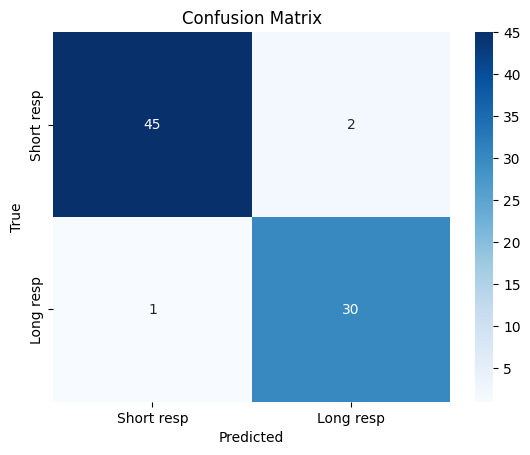

In [25]:
target_names = ['Short resp', 'Long resp']

y_pred = pipeline.predict(x)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Calculated SHAP values

In [26]:
model = pipeline[-1]

x_train_scaled = pipeline[:-1].transform(x_train)   # x -> preprocessed 
x_scaled = pipeline[:-1].transform(x)

feature_names = [
    n.replace('remainder__', '')
     .replace('m_stage__', '')
     .replace('categorical__', '')
     .replace('sex__', '')
     .replace('age__', '')
     .replace('drug_braf__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]

# For binary XGBoost, .values shape is (n_samples, n_features) — log-odds scale, positive class (Long resp)
explainer = shap.TreeExplainer(model, x_train_scaled)
shap_values = explainer(x_scaled)
shap_values.feature_names = feature_names
print(shap_values)

.values =
array([[ 0.11819026,  0.        ,  0.        , ..., -0.06213729,
        -0.62500316, -0.25834384],
       [ 0.20061509,  0.        ,  0.        , ..., -0.08396774,
         0.77344982,  0.40075797],
       [-0.08710952,  0.        ,  0.        , ..., -0.04306824,
        -0.67517423, -0.24445456],
       ...,
       [-0.09246286,  0.        ,  0.        , ..., -0.0446498 ,
        -0.16102023,  0.39905402],
       [ 0.11584049,  0.        ,  0.        , ..., -0.07585138,
        -0.39316018, -0.24048351],
       [-0.08710952,  0.        ,  0.        , ..., -0.0780587 ,
        -0.67528717, -0.24433339]], shape=(78, 34))

.base_values =
array([-0.78966309, -0.78966309, -0.78966309, -0.78966309, -0.78966309,
       -0.78966309, -0.78966309, -0.78966309, -0.78966309, -0.78966309,
       -0.78966309, -0.78966309, -0.78966309, -0.78966309, -0.78966309,
       -0.78966309, -0.78966309, -0.78966309, -0.78966309, -0.78966309,
       -0.78966309, -0.78966309, -0.78966309, -0.78966309

## Plot explanation

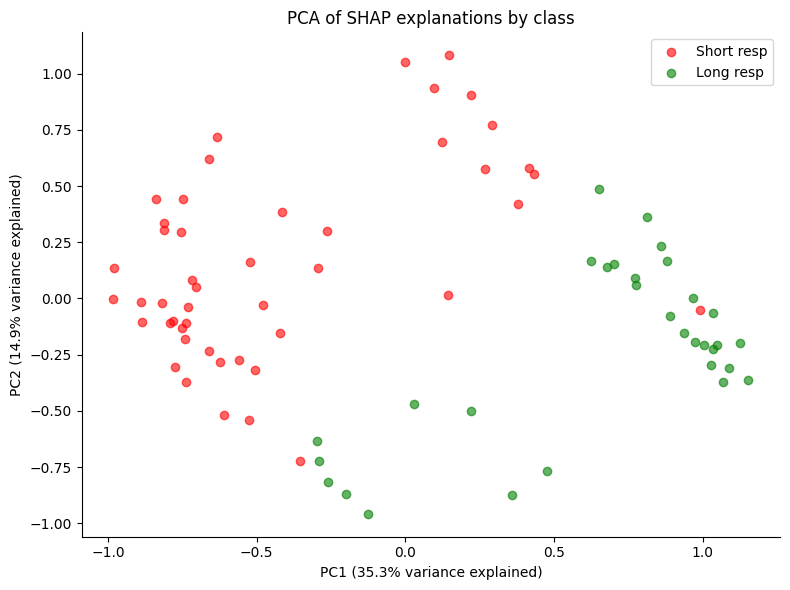

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


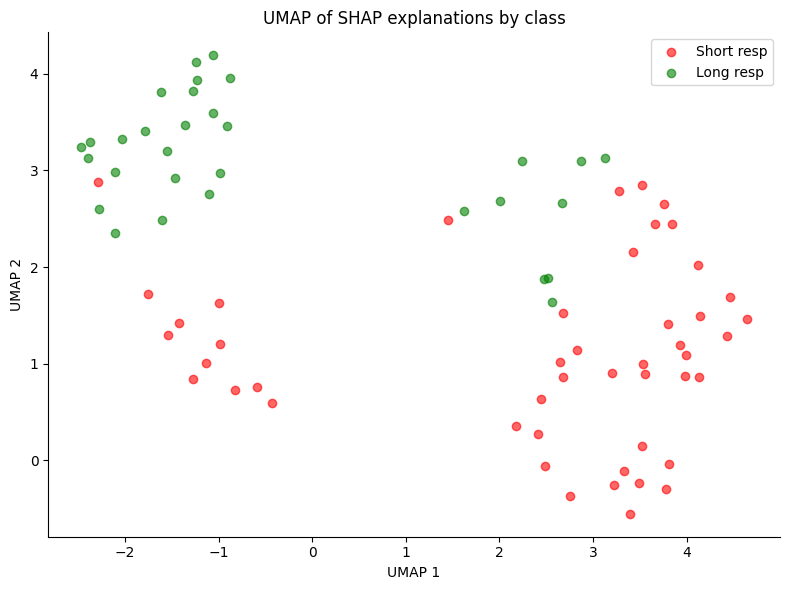

In [27]:
def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# PCA — pass explained variance
pca = PCA(n_components=2)
sv_2d = pca.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")


## Global interpretability

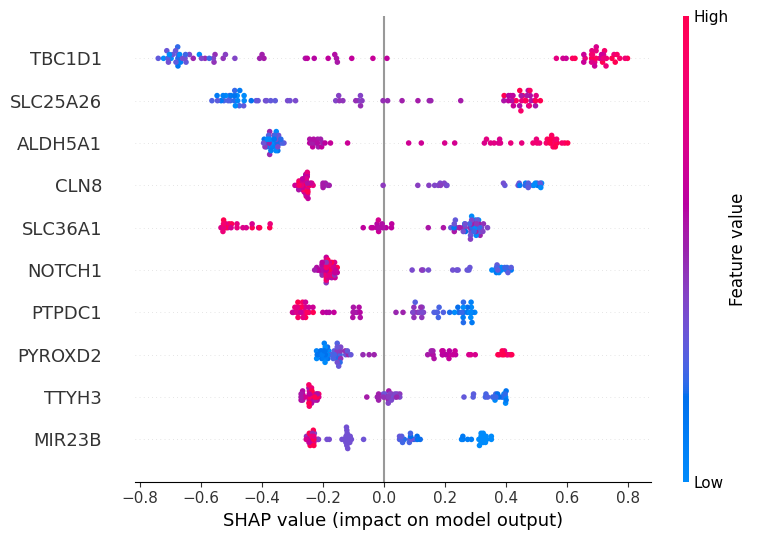

In [28]:
shap.summary_plot(shap_values, x_scaled, feature_names=feature_names, max_display=10)

## Feature × Feature SHAP Interaction Heatmap

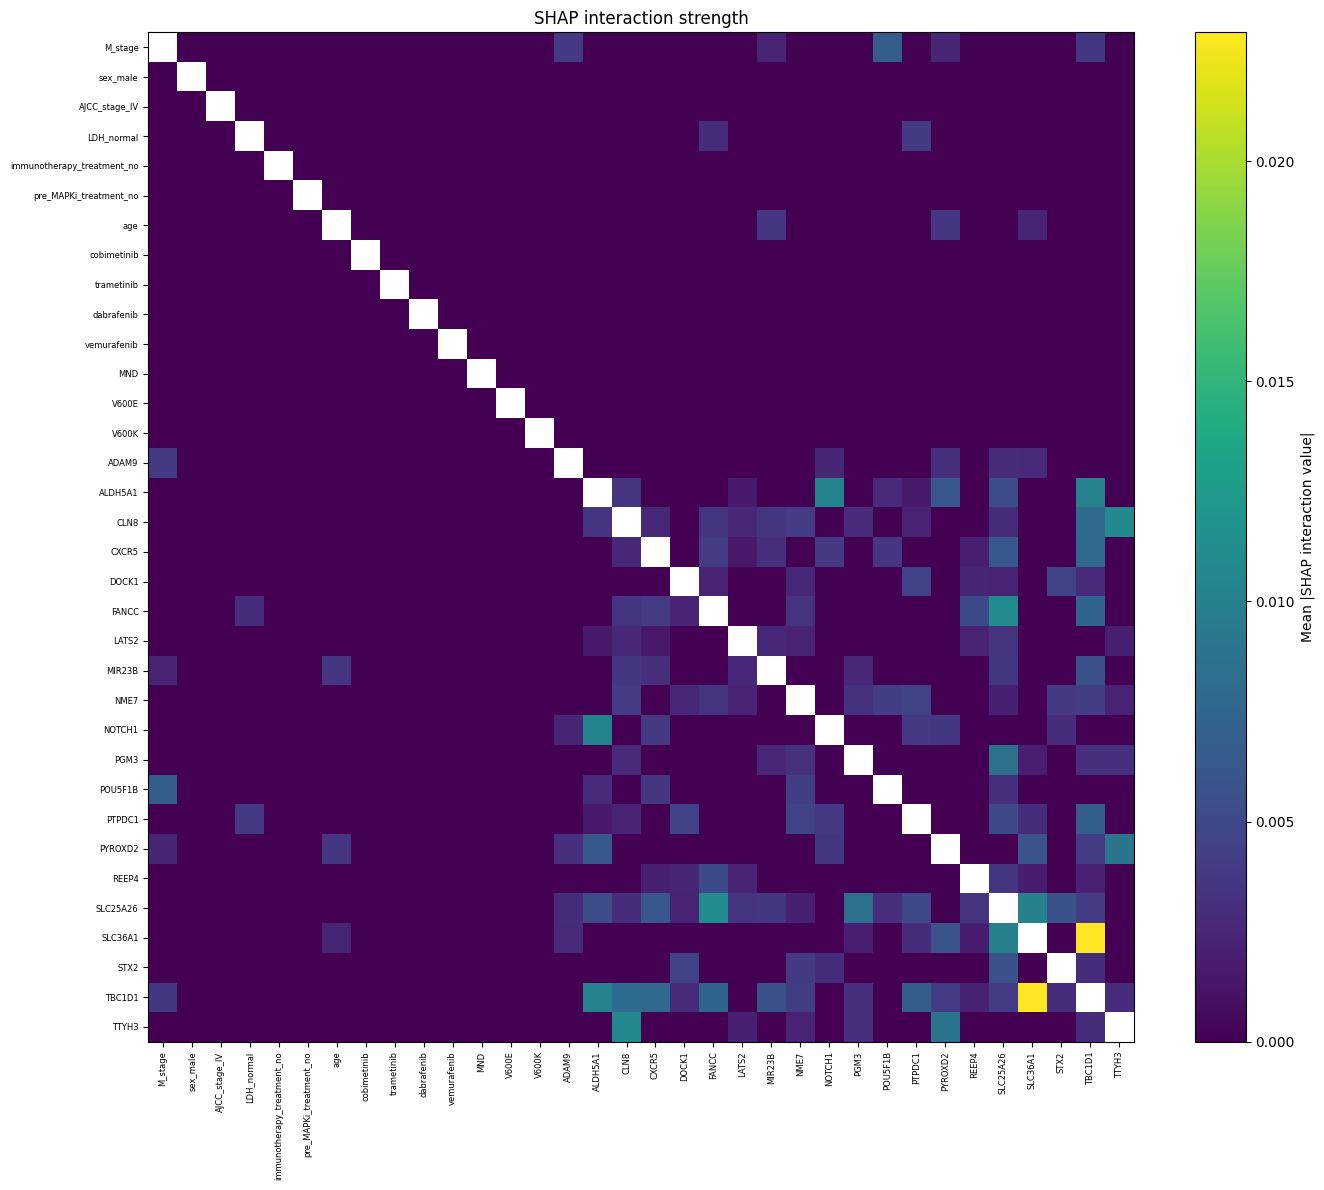

In [ ]:
explainer_interact = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
interaction_values = explainer_interact.shap_interaction_values(x_scaled)

mean_abs_interact = np.abs(interaction_values).mean(axis=0)
interact_df = pd.DataFrame(mean_abs_interact, index=feature_names, columns=feature_names)
np.fill_diagonal(interact_df.values, np.nan)

n_feat = len(feature_names)
data = interact_df.values
vmax = np.nanmax(data)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(data, cmap="viridis", aspect="auto", vmin=0, vmax=vmax)

ax.set_xticks(range(n_feat))
ax.set_yticks(range(n_feat))
ax.set_xticklabels(feature_names, rotation=90, fontsize=6)
ax.set_yticklabels(feature_names, fontsize=6)

for i in range(n_feat):
    for j in range(n_feat):
        val = data[i, j]
        if not np.isnan(val):
            text_color = "white" if val < vmax * 0.6 else "black"

fig.colorbar(im, label="Mean |SHAP interaction value|")
ax.set_title("SHAP interaction strength")
plt.tight_layout()
plt.show()

## Count FP, FN, ... and their log-odds (predicted by model)

In [30]:
y_pred = model.predict(x_scaled)
misclassified = np.where(y_pred != y)[0]
print(f"Misclassified indices: {misclassified}\n")

fp = np.where((y == 0) & (y_pred == 1))[0]  # misclassified short
fn = np.where((y == 1) & (y_pred == 0))[0]  # misclassified long
tn = np.where((y == 0) & (y_pred == 0))[0]   # correctly predicted short
tp = np.where((y == 1) & (y_pred == 1))[0]   # correctly predicted long
print(f'FP (misclassified short): {fp}')
print(f'FN (misclassified long): {fn}')
print(f'TN (correct short): {tn}')
print(f'TP (correct long): {tp}')

Misclassified indices: [13 20 71]

FP (misclassified short): [13 71]
FN (misclassified long): [20]
TN (correct short): [ 0  2  3  4  7 10 11 12 14 16 19 24 25 27 28 29 31 32 35 36 37 38 39 40
 41 42 44 45 48 49 53 54 56 57 59 60 62 64 65 68 70 72 74 76 77]
TP (correct long): [ 1  5  6  8  9 15 17 18 21 22 23 26 30 33 34 43 46 47 50 51 52 55 58 61
 63 66 67 69 73 75]


In [31]:
import xgboost as xgb

# XGBoost has no decision_function — use the booster's raw margin (log-odds)
log_odds = model.get_booster().predict(xgb.DMatrix(x_scaled), output_margin=True)

print(f'FP log-odds: {log_odds[fp]}')
print(f'FN log-odds: {log_odds[fn]}')
print(f'TN log-odds: {log_odds[tn]}')
print(f'TP log-odds: {log_odds[tp]}')

FP log-odds: [0.03736838 2.554202  ]
FN log-odds: [-0.0008959]
TN log-odds: [-1.3948704  -3.2832308  -2.2222428  -2.433817   -3.1633487  -3.935339
 -1.5179359  -3.4036446  -3.760664   -0.8981903  -1.8845948  -0.99885374
 -0.9171612  -3.932742   -1.8979639  -3.2197871  -4.2053084  -2.5933776
 -2.9437857  -2.7413983  -2.7149968  -1.4155651  -3.6447587  -1.7645072
 -3.195537   -3.0119495  -3.9802265  -3.2456856  -2.2321382  -2.8861022
 -3.0756736  -2.303687   -3.8178086  -3.1930943  -1.7850009  -2.7199988
 -1.9171853  -3.9991512  -4.1728706  -2.985742   -2.2558384  -3.2938476
 -3.6578612  -1.4994631  -2.4752426 ]
TP log-odds: [3.0364537  2.4373336  0.967911   3.2222815  1.8776038  1.0301838
 1.2412437  3.1993952  2.6115708  0.9756474  2.8366137  1.4029703
 0.81939393 0.7942573  3.2066836  1.4595478  0.38961762 2.774983
 1.8035873  1.4051386  1.7054628  3.5219622  3.1483722  2.5986595
 2.8025522  1.0830563  1.9723994  0.4324854  1.7781248  0.8567857 ]


## Local interpretability

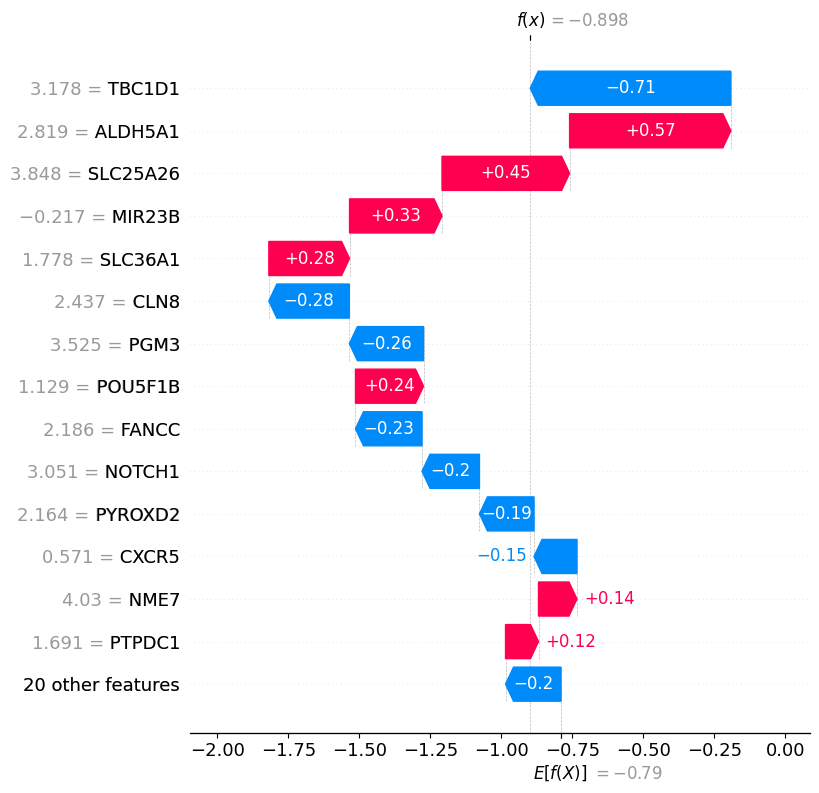

In [32]:
import copy
sv_raw = copy.copy(shap_values)
sv_raw.data = x.values

shap.plots.waterfall(sv_raw[tn[9]], max_display=15)

In [33]:
shap.initjs()
shap.plots.force(sv_raw[tn[35]]) # 9 7 23 35

In [34]:
shap.plots.force(sv_raw[tp[25]]) # 3 18 21 25

## Discovering subgroups

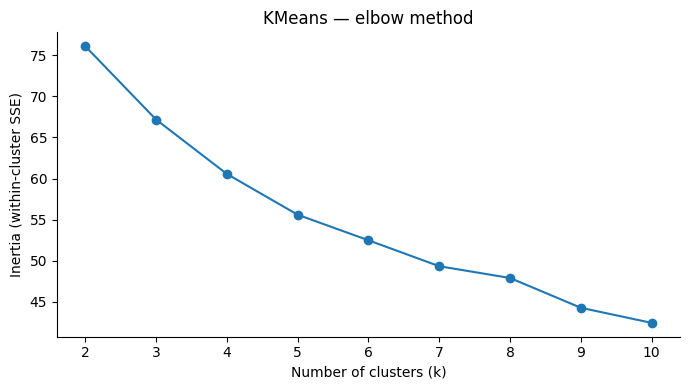

In [35]:
from sklearn.cluster import KMeans

# KMeans elbow
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sv_input)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("KMeans — elbow method")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

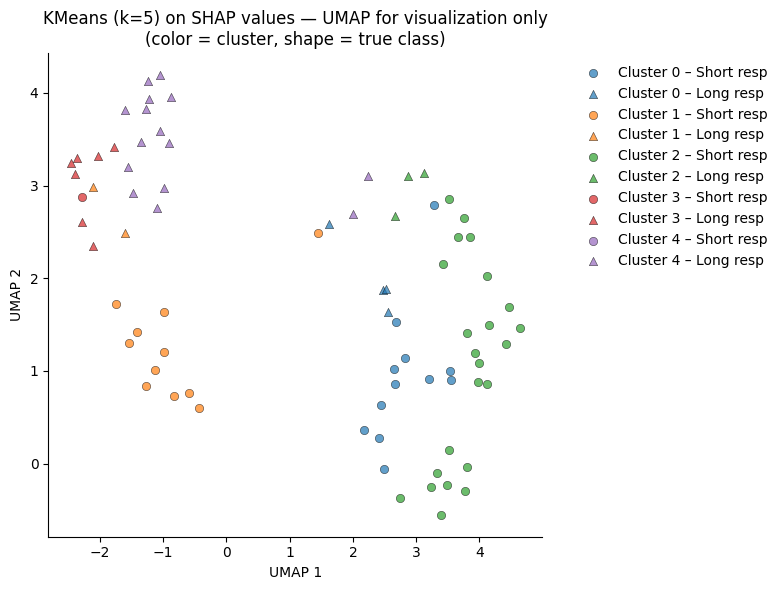

Cluster 0: 12 Short resp, 4 Long resp
Cluster 1: 11 Short resp, 2 Long resp
Cluster 2: 23 Short resp, 3 Long resp
Cluster 3: 1 Short resp, 7 Long resp
Cluster 4: 0 Short resp, 15 Long resp


In [36]:
from sklearn.cluster import KMeans

# cluster in full SHAP space, use sv_2d only for visualization
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(sv_input)

n_clusters = kmeans.n_clusters
cluster_colors = plt.cm.tab10.colors[:n_clusters]
markers = {0: "o", 1: "^"}  # circle=short resp, triangle=long resp

fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_clusters):
    for cls in np.unique(y_arr):
        mask = (cluster_labels == k) & (y_arr == cls)
        label = f"Cluster {k} – {'Short resp' if cls == 0 else 'Long resp'}"
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=[cluster_colors[k]], marker=markers[cls],
            alpha=0.7, label=label, edgecolors="k", linewidths=0.4,
        )

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(f"KMeans (k={n_clusters}) on SHAP values — UMAP for visualization only\n(color = cluster, shape = true class)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for k in range(n_clusters):
    mask = cluster_labels == k
    counts = pd.Series(y_arr[mask]).value_counts().sort_index()
    short = counts.get(0, 0)
    long  = counts.get(1, 0)
    print(f"Cluster {k}: {short} Short resp, {long} Long resp")


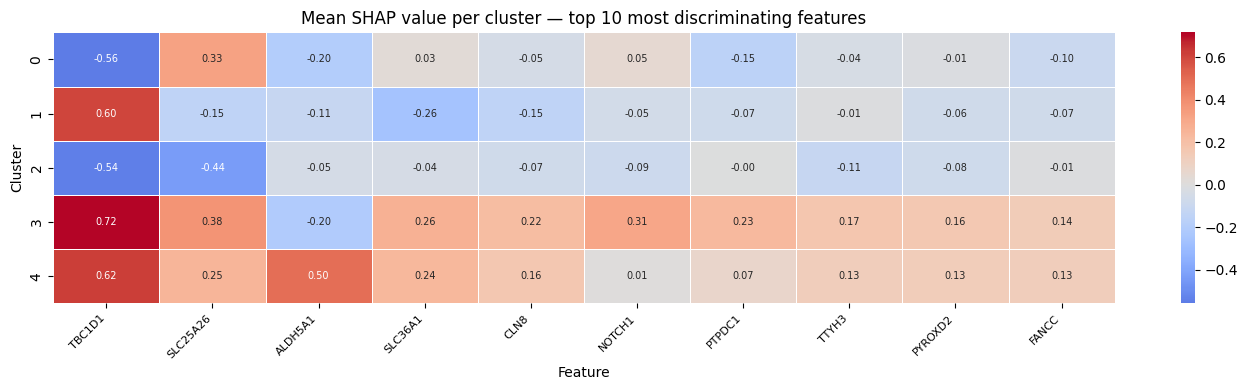

In [37]:
sv_df = pd.DataFrame(shap_values.values, columns=feature_names)
sv_df["cluster"] = cluster_labels

cluster_means = sv_df.groupby("cluster").mean()

# keep top 20 features with highest variance across clusters
top_features = cluster_means.std(axis=0).nlargest(10).index
heatmap_data = cluster_means[top_features]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, ax=ax,
)
ax.set_title(f"Mean SHAP value per cluster — top 10 most discriminating features")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

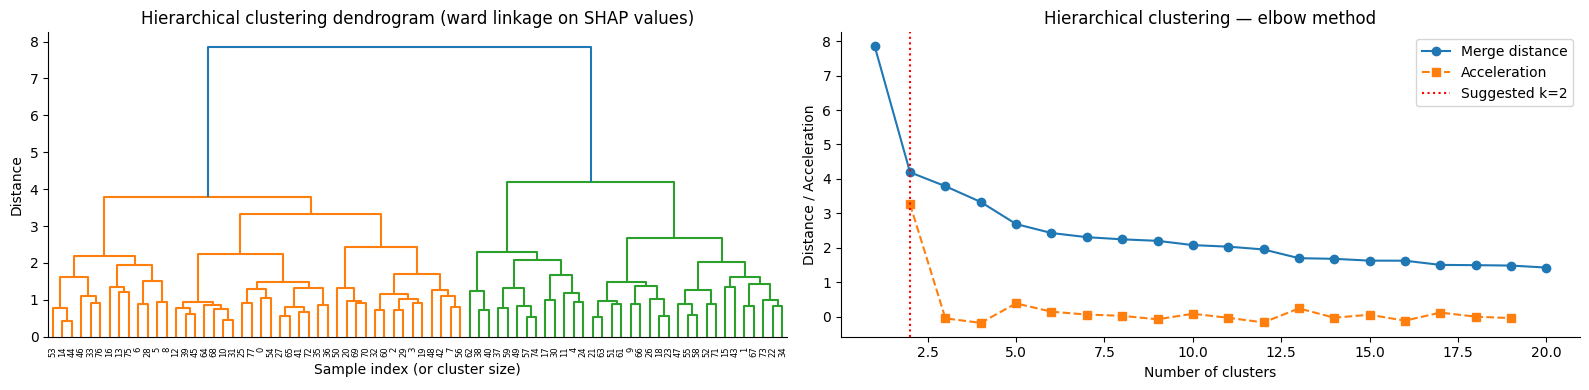

Suggested number of clusters (hierarchical): 2


In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(sv_input, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Dendrogram
dendrogram(Z, ax=axes[0])
axes[0].set_title("Hierarchical clustering dendrogram (ward linkage on SHAP values)")
axes[0].set_xlabel("Sample index (or cluster size)")
axes[0].set_ylabel("Distance")
axes[0].spines[["top", "right"]].set_visible(False)

# Elbow: last merge distances and their acceleration
last = Z[-20:, 2][::-1]          # top 20 merge distances, largest first
acceleration = np.diff(last, 2)   # second derivative — peak = elbow
suggested_k = int(acceleration.argmax()) + 2
idxs = np.arange(1, len(last) + 1)

axes[1].plot(idxs, last, marker="o", label="Merge distance")
axes[1].plot(idxs[1:-1], acceleration, marker="s", linestyle="--", label="Acceleration")
axes[1].axvline(x=suggested_k, color="red", linestyle=":", label=f"Suggested k={suggested_k}")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Distance / Acceleration")
axes[1].set_title("Hierarchical clustering — elbow method")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Suggested number of clusters (hierarchical): {suggested_k}")

Number of clusters at threshold 3: 5


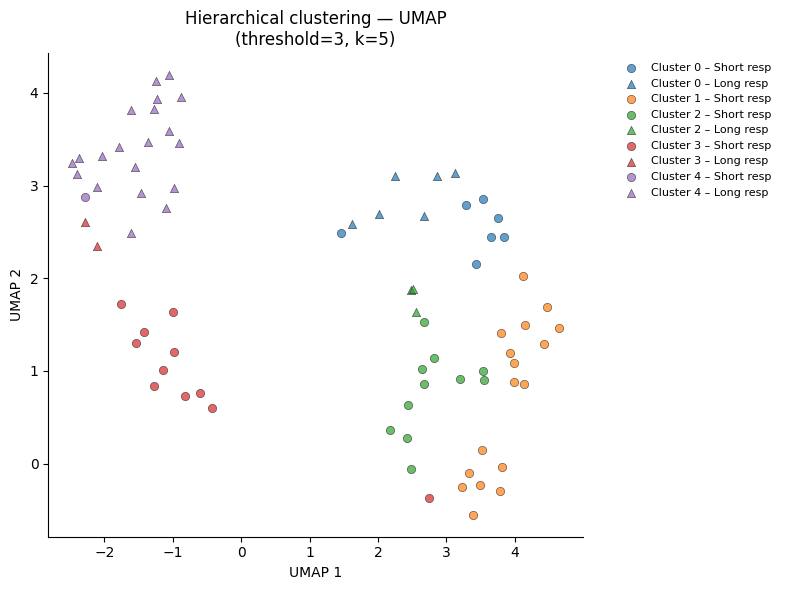

Cluster 0: 7 Short resp, 6 Long resp
Cluster 1: 17 Short resp, 0 Long resp
Cluster 2: 11 Short resp, 3 Long resp
Cluster 3: 11 Short resp, 2 Long resp
Cluster 4: 1 Short resp, 20 Long resp


In [39]:
# --- cut at chosen distance threshold ---
dist_threshold = 3   # adjust based on dendrogram
hier_labels = fcluster(Z, t=dist_threshold, criterion="distance") - 1  # 0-indexed

n_hier = hier_labels.max() + 1
print(f"Number of clusters at threshold {dist_threshold}: {n_hier}")

hier_colors = plt.cm.tab10.colors[:n_hier]
markers = {0: "o", 1: "^"}

fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_hier):
    for cls in np.unique(y_arr):
        mask = (hier_labels == k) & (y_arr == cls)
        if mask.sum() == 0:
            continue
        cls_name = "Short resp" if cls == 0 else "Long resp"
        ax.scatter(sv_2d[mask, 0], sv_2d[mask, 1],
                   c=[hier_colors[k]], marker=markers[cls], alpha=0.7,
                   label=f"Cluster {k} – {cls_name}",
                   edgecolors="k", linewidths=0.4)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(f"Hierarchical clustering — UMAP\n(threshold={dist_threshold}, k={n_hier})")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

for k in range(n_hier):
    mask = hier_labels == k
    counts = pd.Series(y_arr[mask]).value_counts().sort_index()
    print(f"Cluster {k}: {counts.get(0,0)} Short resp, {counts.get(1,0)} Long resp")

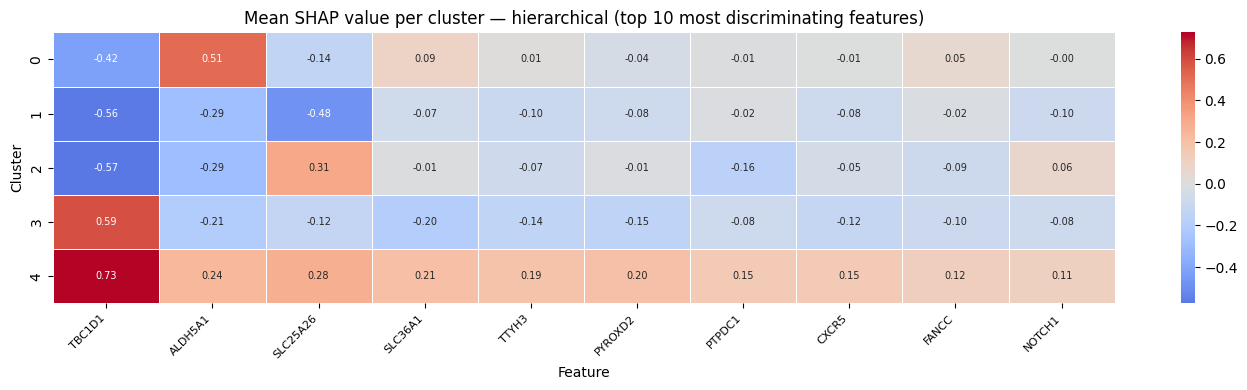

In [40]:
sv_df_hier = pd.DataFrame(shap_values.values, columns=feature_names)
sv_df_hier["cluster"] = hier_labels

cluster_means_hier = sv_df_hier.groupby("cluster").mean()

top_features_hier = cluster_means_hier.std(axis=0).nlargest(10).index
heatmap_data_hier = cluster_means_hier[top_features_hier]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data_hier,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, ax=ax,
)
ax.set_title("Mean SHAP value per cluster — hierarchical (top 10 most discriminating features)")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

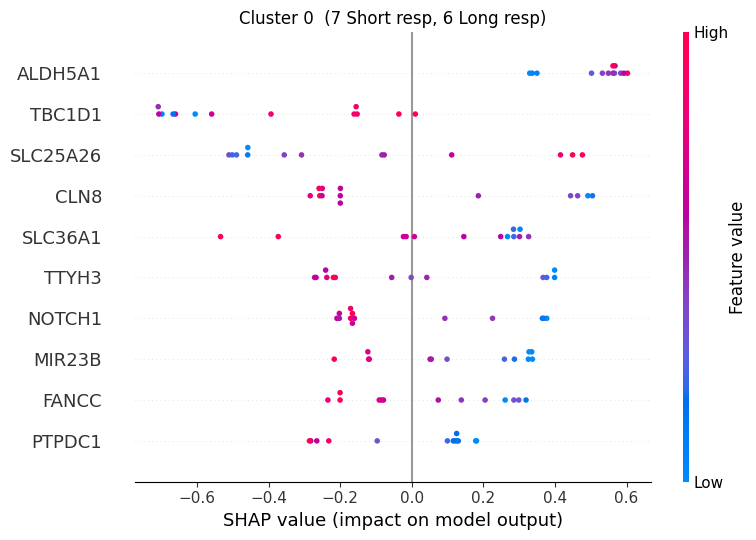

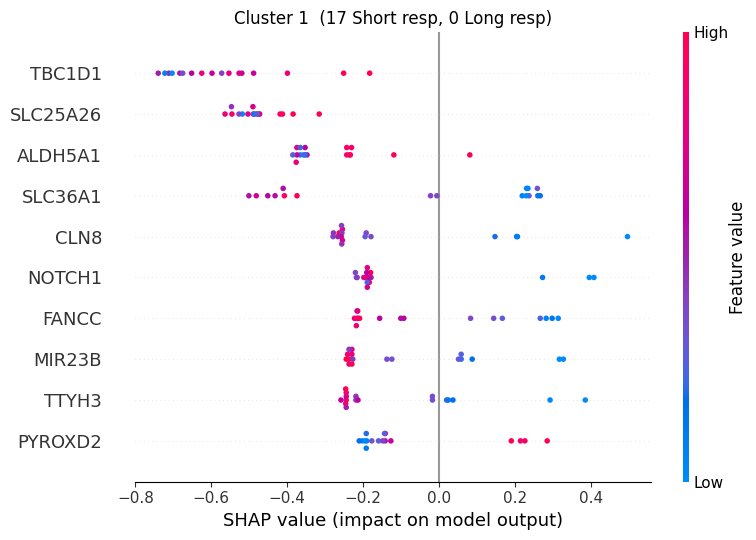

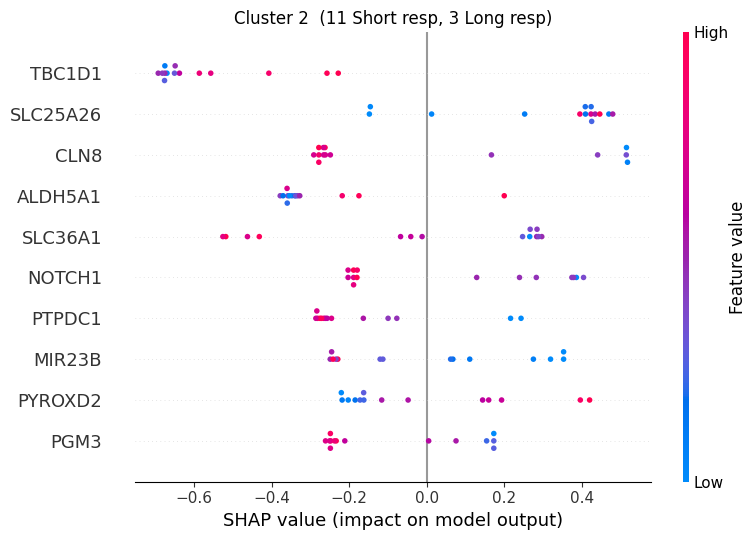

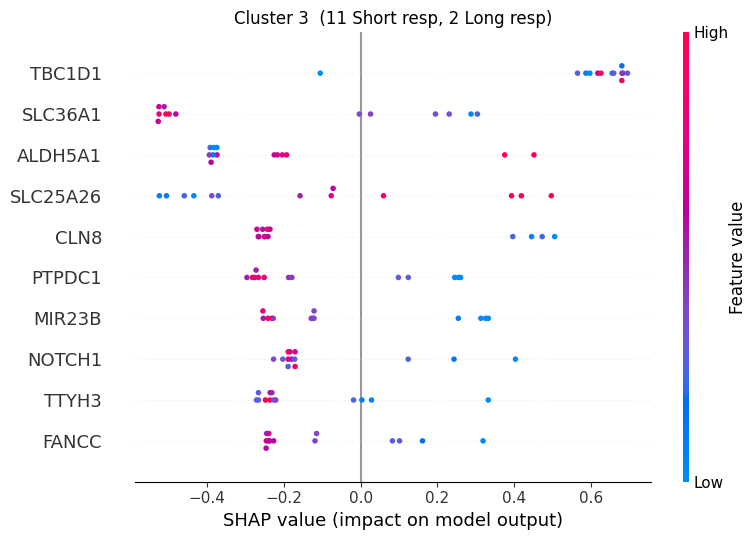

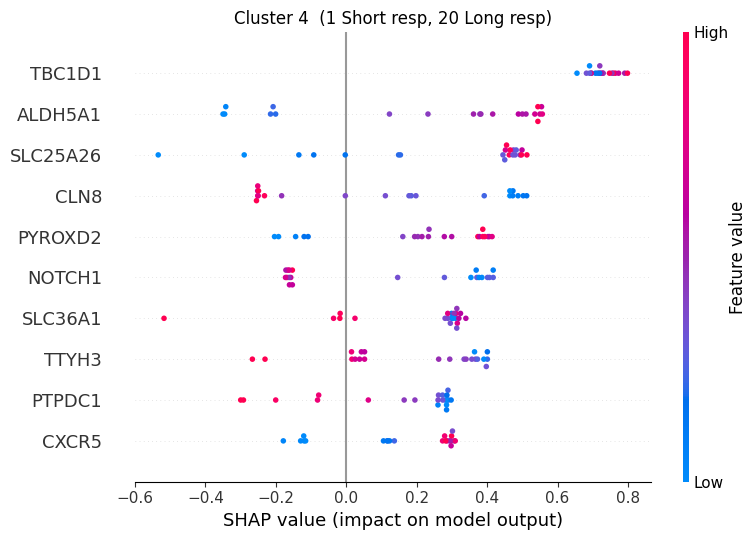

In [41]:
for k in range(n_hier):
    mask = hier_labels == k
    counts = pd.Series(y_arr[mask]).value_counts().sort_index()
    short, long_ = counts.get(0, 0), counts.get(1, 0)

    shap.summary_plot(
        shap_values[mask],
        x_scaled[mask],
        feature_names=feature_names,
        max_display=10,
        show=False,
    )
    plt.title(f"Cluster {k}  ({short} Short resp, {long_} Long resp)")
    plt.tight_layout()
    plt.show()

In [42]:
from imodels import SkopeRulesClassifier

# One-hot encode categoricals so SkopeRules gets numeric input;
# get_dummies keeps names like "m_stage_M1B" which remain clinically readable.
x_encoded = pd.get_dummies(x).reset_index(drop=True)
feature_cols = list(x_encoded.columns)
x_raw = x_encoded.values.astype(float)

print("=" * 70)
print("Skope-Rules — decision rules per hierarchical cluster (raw features)")
print("=" * 70)

for k in range(n_hier):
    binary_target = (hier_labels == k).astype(int)
    n_pos = int(binary_target.sum())

    sr = SkopeRulesClassifier(
        precision_min=0.70,      # was 0.5 — catch more rules
        recall_min=0.55,         # was 0.5 — catch more rules
        random_state=42,
        n_estimators=50,         # was 10 — much more diverse rules
        max_depth=3,             # keep
        max_depth_duplication=2, # was 2 — allow slightly more overlap
        # max_features=0.8,        # add this — feature diversit
    )
    sr.fit(x_raw, binary_target, feature_names=feature_cols)

    counts = pd.Series(y_arr[hier_labels == k]).value_counts().sort_index()
    short, long_ = counts.get(0, 0), counts.get(1, 0)
    print(f"\nCluster {k}  ({n_pos} patients — {short} Short resp, {long_} Long resp)")
    print("-" * 50)

    if sr.rules_:
        for rule, (prec, rec, n) in sr.rules_:
            print(f"  IF {rule}")
            print(f"     → precision={prec:.2f}  recall={rec:.2f}  support={n}")
    else:
        print("  No rules found (try lowering precision_min / recall_min)")

Skope-Rules — decision rules per hierarchical cluster (raw features)

Cluster 0  (13 patients — 7 Short resp, 6 Long resp)
--------------------------------------------------
  IF ALDH5A1 > 2.17987 and TBC1D1 <= 3.72866
     → precision=1.00  recall=1.00  support=2
  IF ALDH5A1 > 2.25356 and PGM3 > 3.1562 and REEP4 > 3.39711
     → precision=1.00  recall=0.75  support=1

Cluster 1  (17 patients — 17 Short resp, 0 Long resp)
--------------------------------------------------
  IF ALDH5A1 <= 2.13559 and SLC25A26 <= 3.03454 and TBC1D1 <= 3.72439
     → precision=1.00  recall=1.00  support=2
  IF SLC25A26 <= 2.99271 and sex_female <= 0.5
     → precision=1.00  recall=0.75  support=1

Cluster 2  (14 patients — 11 Short resp, 3 Long resp)
--------------------------------------------------
  IF ALDH5A1 <= 2.16776 and SLC25A26 > 3.08899 and TBC1D1 <= 3.63844
     → precision=1.00  recall=1.00  support=1

Cluster 3  (13 patients — 11 Short resp, 2 Long resp)
-------------------------------------